In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

url = "risk_factors_cervical_cancer.csv"
df = pd.read_csv(url, na_values='?')

print(f"Dataset cargado correctamente. Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.\n")
df.head()

Dataset cargado correctamente. Dimensiones: 858 filas y 36 columnas.



,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


Rodrigo: 09/06/26- Segun la rubrica los archivos correspondientes al modelo se tendran que exportar para subirlos al repositorio compartido de github, para esto e añadido la libreria "joblib", busque y eso nos ayuda para hacerlo.

```
import joblib
```
Rodrigo: 09/06/26- Subiendo el archivo CSV que no proporciono el profe, la data la asigne a la variable url para poder trabajar con ella. Tambien converti el csv a un dataframe para poder trabajar las variables con "?" que encontre al abrir el archivo, simplemente las remplace por el valor generico de NAN que tiene la funcion "read_csv()"

Rodrigo: 09/06/26- La carga fue Exitosa


In [ ]:

missing_summary = pd.DataFrame({
    'Total Nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df)) * 100
}).sort_values(by='Total Nulos', ascending=False)

missing_summary = missing_summary[missing_summary['Total Nulos'] > 0]

missing_summary

,Total Nulos,Porcentaje (%)
STDs: Time since first diagnosis,787,91.724942
STDs: Time since last diagnosis,787,91.724942
IUD,117,13.636364
IUD (years),117,13.636364
Hormonal Contraceptives,108,12.587413
Hormonal Contraceptives (years),108,12.587413
STDs:HPV,105,12.237762
STDs:AIDS,105,12.237762
STDs:Hepatitis B,105,12.237762
STDs:HIV,105,12.237762


Rodrigo: 09/06/26- Antes de limpiar nada en el dataset debemos de buscar el porcentaje de datos faltantes en cada columna, para saber si dejarlas o eliminarlas de nuestro analisis. Para esto calcule lso valores de cantidad de nulos y porcentaje de nulos para poder evaluar todas las columnas y saber cuales conservar y cuales no.

Rodrigo: 09/06/26-
En caso alguien no entienda el siguiente fragmento de codigo:
```
missing_summary = missing_summary[ missing_summary['Total Nulos'] > 0 ]
```
Se le asigna a la variable que ya se habia llenado de datos anteriormente "missing_summary" la misma data missing_summary solo que filtrada bajo en campo de "Total de nulos" y solo si esta es mayor a 0 se muestra.


In [ ]:

umbral = 90.0
porcentajes_nulos = (df.isnull().sum() / len(df)) * 100

columnas_a_eliminar = porcentajes_nulos[porcentajes_nulos > umbral].index.tolist()

print(f"Columnas detectadas automáticamente para eliminar (>{umbral}% nulos): {columnas_a_eliminar}")

df_clean = df.drop(columns=columnas_a_eliminar)

#--------------------------------------------------------------------------------------------------------------


columnas_continuas = [
    'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies',
    'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives (years)', 'IUD (years)'
]
for col in columnas_continuas:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

columnas_categoricas = [
    'Smokes', 'Hormonal Contraceptives', 'IUD', 'STDs', 'STDs (number)',
    'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis',
    'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease',
    'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV',
    'STDs:Hepatitis B', 'STDs:HPV'
]
for col in columnas_categoricas:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Total de valores nulos pendientes:", df_clean.isnull().sum().sum())

Columnas detectadas automáticamente para eliminar (>90.0% nulos): ['STDs: Time since first diagnosis', 'STDs: Time since last diagnosis']
Total de valores nulos pendientes: 0


Rodrigo: 09/06/26- En la primera division del este codigo, obtenemos las columnas que superan el limite del 90% de elementos faltantes, por ende deben de ser retirados del dataset. Estas columnas estan contenidas en al variable columnas a eliminar, las muestra y ya luego solo se eliminan con la funcion "drop".


Rodrigo: 09/06/26- La segunda mitad solo rellena con mediana y moda respectivamente las viariables que aun contienen valores faltantes en menor medida. Previamente ya fueron evaluadas al ver el CSV para saber cuales son categoricas y cuales continuas.


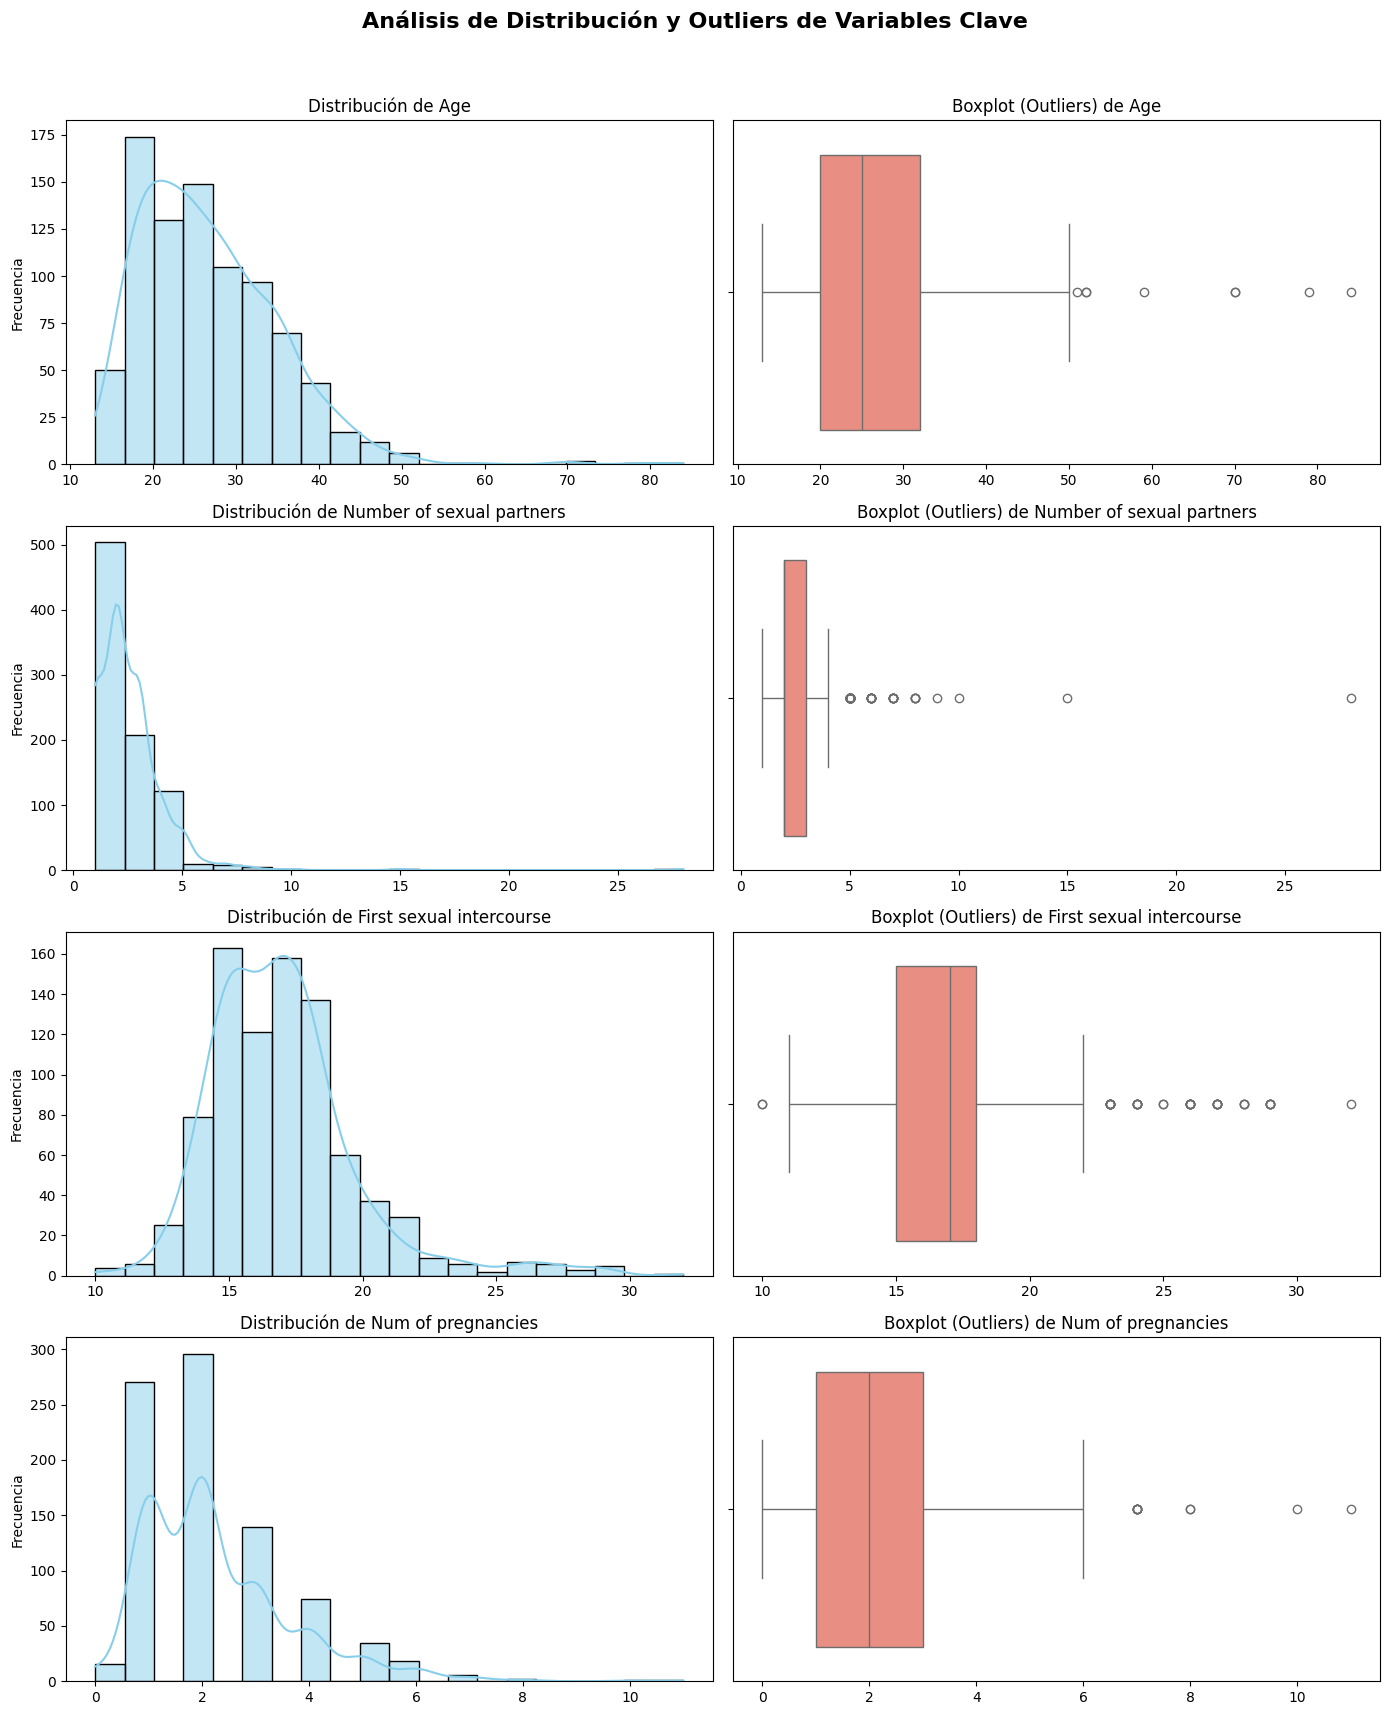

In [ ]:

variables_analisis = ['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies']

#Matriz
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))
fig.suptitle('Análisis de Distribución y Outliers de Variables Clave', fontsize=16, fontweight='bold', y=0.95)

for i, col in enumerate(variables_analisis):

    sns.histplot(df_clean[col], kde=True, ax=axes[i, 0], color='skyblue', bins=20)
    axes[i, 0].set_title(f'Distribución de {col}', fontsize=12)
    axes[i, 0].set_xlabel('')
    axes[i, 0].set_ylabel('Frecuencia')


    sns.boxplot(x=df_clean[col], ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'Boxplot (Outliers) de {col}', fontsize=12)
    axes[i, 1].set_xlabel('')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

Rodrigo: 10/06/26- Seleccione algunas variables para poder ver graficamente los outliers y la distribucion de los datos. Para esto use boxplot para hayar los outliers e histogramas solo para visualizar las cantidades.
*   Los histogramas contienen la curva de densidad KDE (Sugerido por google)



In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE

X = df_clean.drop(columns=['Biopsy', 'Hinselmann', 'Schiller', 'Citology'])
y = df_clean['Biopsy']

#Separación de datos de entrenamiento y de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)


selector = SelectKBest(score_func=f_classif, k=15)
X_train_selected = selector.fit_transform(X_train_scaled_df, y_train)
X_test_selected = selector.transform(X_test_scaled)


columnas_seleccionadas = X.columns[selector.get_support()].tolist()

#Generacion sintetica de positivos (no habian tantos para que se puedan repartir)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_selected, y_train)

print("INGENIERÍA DE CARACTERÍSTICAS COMPLETADA:")
print(f"- Características seleccionadas para los modelos: {columnas_seleccionadas}")
print(f"- Dataset de entrenamiento original: {X_train.shape[0]} registros.")
print(f"- Dataset de entrenamiento balanceado con SMOTE: {X_train_resampled.shape[0]} registros.")

INGENIERÍA DE CARACTERÍSTICAS COMPLETADA:
- Características seleccionadas para los modelos: ['Age', 'Smokes (years)', 'Hormonal Contraceptives (years)', 'IUD', 'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:HIV', 'STDs: Number of diagnosis', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx']
- Dataset de entrenamiento original: 686 registros.
- Dataset de entrenamiento balanceado con SMOTE: 1284 registros.


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [14 19 21] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(


Rodrigo: 10/06/26- Aviso que las viariables son asi:
*   Y = nuestra variable objetivo (osea sabe si la pasiente tiene riesgo o no)
*  X = conjunto de variables con las que evaluaremos, eliminando los demas examenes clinicos que solo afectarian nuestros resultados ya que se realizan casi en paralelo con la biopsia que es nuestro objetivo. De esta forma forzamos al modelo a predecir con los datos que realmente necesitamos.

Rodrigo: 10/06/26- OJO, al estar separando el dataset para entrenamiento, la primera vez la districubcion de pasientes dectectadas con positivo estaba desproporcionado y en los de entrenamiento no ingresaron ni un caso positivo asi que tras consultar a google y geminy, me arrojaron como resultado que debe ingresarse:
```
stratify=y
```
con el objetivo de que los porcentajes de pasientes que den positivo y negativo sean los mismos en los dataset de entrenamiento como en el original.



Rodrigo: 10/06/26- Use la prueba anova para seleccionar las 15 mejores variables:
```
selector = SelectKBest(score_func=f_classif, k=15)
```



## Modelo 1 - Regresión Logística con Regularización
\

In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix


lr_base = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

param_grid_lr = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}


grid_lr = GridSearchCV(estimator=lr_base, param_grid=param_grid_lr, cv=5, scoring='f1', n_jobs=-1)

#Entrenar el modelo con la data que ya sacamos del SMOTE
grid_lr.fit(X_train_resampled, y_train_resampled)

#Guardar el mejor modelo
best_lr_model = grid_lr.best_estimator_

#Realizar primeras Pruebas
y_pred_lr = best_lr_model.predict(X_test_selected)

print("OPTIMIZACIÓN DE REGRESIÓN LOGÍSTICA COMPLETADA:")
print(f"- Mejores hiperparámetros encontrados: {grid_lr.best_params_}")
print("\n REPORTE DE CLASIFICACIÓN EN EL SET DE PRUEBA:")
print(classification_report(y_test, y_pred_lr))

OPTIMIZACIÓN DE REGRESIÓN LOGÍSTICA COMPLETADA:
- Mejores hiperparámetros encontrados: {'C': 1, 'penalty': 'l1'}

 REPORTE DE CLASIFICACIÓN EN EL SET DE PRUEBA:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       161
           1       0.18      0.36      0.24        11

    accuracy                           0.85       172
   macro avg       0.57      0.63      0.58       172
weighted avg       0.90      0.85      0.88       172



Rodrigo: 11/06/26- Inicializa el algoritmo base de Regresión Logística.
```
lr_base = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
```
Rodrigo: 11/06/26- el grid permite las separacion de penalizaciones en lasso = l1 (elimina) y en Ridge = l2 (deprime los pesos) ademas de establecer las regulaciones con C

*   Lasso (L1): Realiza selección de atributos al reducir a cero los coeficientes de variables redundantes, eliminándolas.
*   Ridge (L2): Reduce la magnitud de los pesos (encogimiento) aproximándolos a cero para mitigar la multicolinealidad, pero los mantiene en el modelo.

El parámetro C regula la fuerza: valores muy pequeños (como 0.001) penalizan fuertemente al modelo para evitar el sobreajuste, mientras que valores altos (como 100) le dan más libertad.


Rodrigo: 11/06/26- Ya configure la busqueda en el grid por medio de la combinacion de parametros, ademas separe los datos de entrenamiento en 5 partes, 4 para entrenar y 1 para evaluar, y de ahi va rotando 5 veces cambiando cada combinacion, esto serian en total 60 entrenamientos.
```
grid_lr = GridSearchCV(estimator=lr_base, param_grid=param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
```
OJO: Segun google es impresindible colocar "scoring='f1'" para ordenar que el modelo que se use sea el que le da mejor equilibrio a los casos positivos.
y como ultimo aviso:

```
 n_jobs=-1
```
esto solo activa todos los nucleos para que trabaje mas rapido, me lo recomendo el mismo colab,


# Modelo 2 - Redes Neuronales (Perceptrón Multicapa - MLP)

In [ ]:

from sklearn.neural_network import MLPClassifier

mlp_base = MLPClassifier(max_iter=500, random_state=42)

param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (30, 15), (50, 25)],
    'activation': ['tanh', 'relu'],
    'alpha': [0.0001, 0.001, 0.01]
}


grid_mlp = GridSearchCV(estimator=mlp_base, param_grid=param_grid_mlp, cv=5, scoring='f1', n_jobs=-1)

#Entrenar el modelo
grid_mlp.fit(X_train_resampled, y_train_resampled)

#Guardar el mejor modelo
best_mlp_model = grid_mlp.best_estimator_

#Realizar primeras Pruebas
y_pred_mlp = best_mlp_model.predict(X_test_selected)

print("OPTIMIZACIÓN DE RED NEURONAL COMPLETADA:")
print(f"- Mejores hiperparámetros encontrados: {grid_mlp.best_params_}")
print("\nREPORTE DE CLASIFICACIÓN (RED NEURONAL) EN EL SET DE PRUEBA:")
print(classification_report(y_test, y_pred_mlp))

OPTIMIZACIÓN DE RED NEURONAL COMPLETADA:
- Mejores hiperparámetros encontrados: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (50, 25)}

REPORTE DE CLASIFICACIÓN (RED NEURONAL) EN EL SET DE PRUEBA:
              precision    recall  f1-score   support

           0       0.94      0.81      0.87       161
           1       0.06      0.18      0.09        11

    accuracy                           0.77       172
   macro avg       0.50      0.50      0.48       172
weighted avg       0.88      0.77      0.82       172



Rodrigo: 11/06/26- Inicializar la red neuronal.
```
mlp_base = MLPClassifier(max_iter=500, random_state=42)
```
Rodrigo: 11/06/26- El grid de parametros esta mapeado con las siguiente alternativas:
*  Una sola capa oculta de 50 neuronas
*  Una estructura de dos capas ocultas, una de 30 y una de 15 neuronas
*  Una estructura de dos capas oculatas, una de 50 y otra de 25 neuronas

La parte de activacion lo que hace es introducir el factor de no linealidad al modelo, esto lo logra evaluando tanto la tangente hipervolica frente a la unidad lineal. (tanh y relu respectivamente).

La parte de alpha res como la C del modelo lineal, es el coeficiente de regulacion ridge, penaliza cuando los ruidos crecen demaciado para que la red evite memorizar el ruido durante el entrenamiento.




# Modelo 3 - Árboles Avanzados (LightGBM)

In [ ]:


import lightgbm as lgb

lgb_base = lgb.LGBMClassifier(random_state=42, verbose=-1)

param_grid_lgb = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

grid_lgb = GridSearchCV(estimator=lgb_base, param_grid=param_grid_lgb, cv=5, scoring='f1', n_jobs=-1)

#Entrenar el modelo
grid_lgb.fit(X_train_resampled, y_train_resampled)

#Guardar el mejor modelo
best_lgb_model = grid_lgb.best_estimator_

#Realizar primeras Pruebas
y_pred_lgb = best_lgb_model.predict(X_test_selected)

print("OPTIMIZACIÓN DE LIGHTGBM COMPLETADA:")
print(f"- Mejores hiperparámetros encontrados: {grid_lgb.best_params_}")
print("\nREPORTE DE CLASIFICACIÓN (LIGHTGBM) EN EL SET DE PRUEBA:")
print(classification_report(y_test, y_pred_lgb))

OPTIMIZACIÓN DE LIGHTGBM COMPLETADA:
- Mejores hiperparámetros encontrados: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 150}

REPORTE DE CLASIFICACIÓN (LIGHTGBM) EN EL SET DE PRUEBA:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       161
           1       0.10      0.09      0.10        11

    accuracy                           0.89       172
   macro avg       0.52      0.52      0.52       172
weighted avg       0.88      0.89      0.89       172



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Rodrigo: 16/06/26- Inicializar la red neuronal
```
lgb_base = lgb.LGBMClassifier(random_state=42, verbose=-1)
```
Rodrigo: 11/06/26- El grid de parametros esta mapeado con las siguiente alternativas:


*   n estimators: Especifica la cantidad total de árboles de decisión secuenciales que se van a construir.
*   learning_rate: Controla el impacto que tiene cada nuevo árbol al corregir los errores cometidos por los árboles anteriores. Un valor pequeño (0.01) aprende de manera muy precisa pero requiere más estimadores; un valor alto (0.1) acelera la convergencia pero puede saltarse la solución óptima.
*  max_depth: Es el número máximo de preguntas seguidas que el árbol tiene permitido hacer para llegar a una respuesta





# Comparativa de Modelos y Métricas de Rendimiento

TABLA COMPARATIVA GENERAL:


,Accuracy,Recall (Clase 1),F1-Score (Clase 1)
Regresión Logística,0.854651,0.363636,0.242424
Red Neuronal (MLP),0.773256,0.181818,0.093023
LightGBM,0.889535,0.090909,0.095238


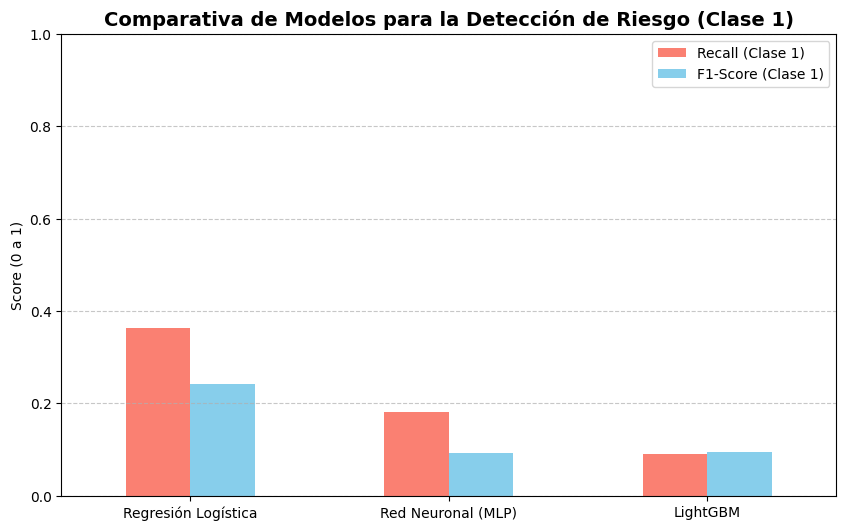

In [ ]:

from sklearn.metrics import f1_score, recall_score, accuracy_score

modelos_nombres = ['Regresión Logística', 'Red Neuronal (MLP)', 'LightGBM']

metricas = {
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_mlp),
        accuracy_score(y_test, y_pred_lgb)
    ],
    'Recall (Clase 1)': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_mlp),
        recall_score(y_test, y_pred_lgb)
    ],
    'F1-Score (Clase 1)': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_mlp),
        f1_score(y_test, y_pred_lgb)
    ]
}

df_comparativa = pd.DataFrame(metricas, index=modelos_nombres)
print("TABLA COMPARATIVA GENERAL:")
display(df_comparativa)


#Graficas
df_comparativa[['Recall (Clase 1)', 'F1-Score (Clase 1)']].plot(kind='bar', figsize=(10, 6), color=['salmon', 'skyblue'])
plt.title('Comparativa de Modelos para la Detección de Riesgo (Clase 1)', fontsize=14, fontweight='bold')
plt.ylabel('Score (0 a 1)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.ylim(0, 1)
plt.show()

Rodrigo: 16/06/26- Para poder hallar las metricas y comprar los resultados de los modelos traigo evaluadores prearmados en la libreria sklearn.metrics. Con esto armo un diccionario que contenga los valores respectivos tanto de la exactitud, el recall y el F1-Score.
El diccionario luego lo converti en un dataframe para poder mostrarse como una tabla almacenada en df_comparativa.


Rodrigo: 16/06/26- Utilice el siguiente Promt para graficar los datos optenidos con el objetivo de optimizar tiempos:
* Promt:
*Generar un código en Python usando Matplotlib y Pandas para graficar un diagrama de barras comparativo que muestre las métricas de Recall y F1-Score (Clase 1) de tres modelos de clasificación entrenados*


# Explicación usando SHAP

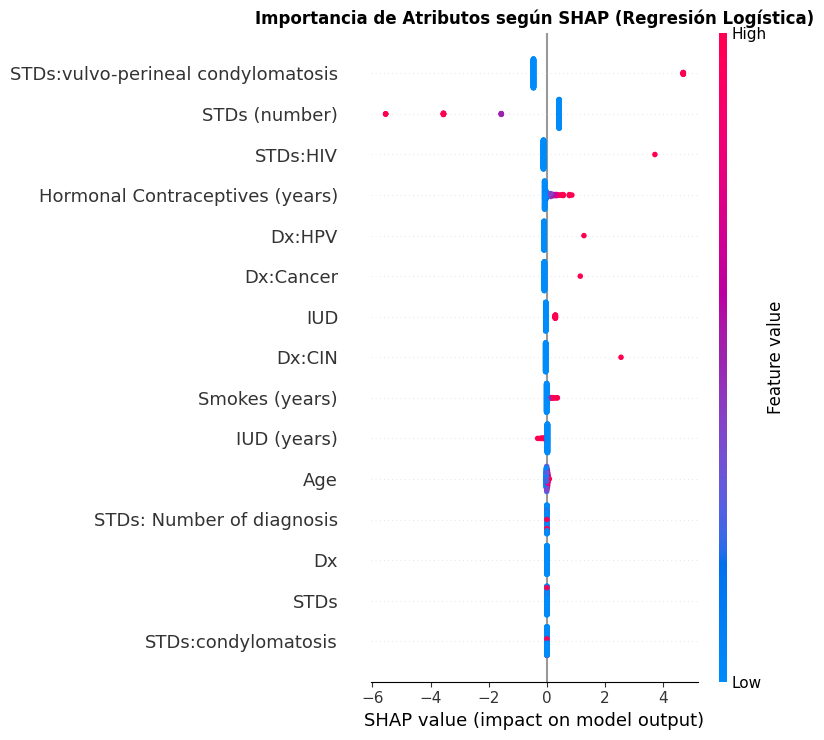

In [ ]:

import shap

explainer = shap.LinearExplainer(best_lr_model, X_train_resampled)
shap_values = explainer(X_test_selected)

#Dibuja el Sumary Plot
plt.title('Importancia de Atributos según SHAP (Regresión Logística)', fontsize=12, fontweight='bold')
shap.summary_plot(shap_values, X_test_selected, feature_names=columnas_seleccionadas)

Rodrigo: 19/06/26- Segun lo investigado en google bajo los estandares de explicabilidad de los modelos de machine learning, el estandar es: "SHapley Additive exPlanations" el cual cuenta con su pripia libreria "shap".

Rodrigo: 19/06/26- Al encontrar que el mejor modelo para el caso fue el de regreson logistica, utilizamos linearExplainer para la variable del explicador, se le entrega el mejor modelo de los que evalue en logistica y tambien la data con la que lo entrene para que entienda el contexto.

Rodrigo: 19/06/26- El explicador analiza a las pacientes del grupo de prueba (X_test_selected) y luego calcula cuántos "puntos" a favor o en contra aporta cada característica para llegar al diagnóstico de cada una de ellas.

# Exportacion del Modelo

In [ ]:

import joblib

#Guardar los mejores modelos entrenados
joblib.dump(best_lr_model, 'modelo_regresion_logistica.pkl')
joblib.dump(best_mlp_model, 'modelo_red_neuronal.pkl')
joblib.dump(best_lgb_model, 'modelo_lightgbm.pkl')

#Guardar también el escalador y el selector de atributos
joblib.dump(scaler, 'escalador_robust.pkl')
joblib.dump(selector, 'selector_atributos.pkl')


print("- Los 3 modelos sintonizados han sido guardados como archivos .pkl")
print("- El escalador y selector estadístico han sido serializados correctamente.")

💾 ¡Fase de Código Oficialmente Concluida!
- Los 3 modelos sintonizados han sido guardados como archivos .pkl
- El escalador y selector estadístico han sido serializados correctamente.


Rodrigo: 22/06/26- Segun Google es importante guardar el escalador y el selector de atributos para que sea posible procesar nuevos datos de pacientes en el futuro sin fuga de datos.